# 1.1 Quantizer — 실수 파형을 `int16` 으로 · Normal ∥ Masked

## 이 노트북이 답하는 질문

SCALib 의 모든 분석기는 파형을 **`int16`** 으로 받는다. 그런데 오실로스코프가 주는 값은
실수다. **어떻게 정수로 옮겨야 정보를 잃지 않는가?**

`scalib.preprocessing.Quantizer` 가 그 변환을 맡는다.

| | |
|---|---|
| 입력 | 두 타겟의 `/explore` |
| 하드웨어 | 불필요. `1.0.SNR` 선행 필요 (POI 와 `enc_start` 를 쓴다) |

**두 타겟을 같이 보는 이유:** 마스킹 구현은 파형이 더 길고 연산 구성도 달라 진폭 분포가
다르다. 같은 양자화 절차가 두 파형 모두에서 안전한지 확인한다.

## 왜 그냥 곱해서 반올림하면 안 되는가

`int16` 이 담을 수 있는 범위는 −32,768 ~ 32,767 이다. 잘못될 수 있는 방향은 둘이다.

| 실수 | 결과 |
|------|------|
| 배율이 너무 작다 | 파형이 몇 개 정수 계단에만 걸린다. **양자화 잡음이 신호를 덮는다** |
| 배율이 너무 크다 | 범위를 넘는 값이 잘린다(clipping) |

두 번째는 흔히 "잘리면 정보가 사라진다" 고 뭉뚱그려 말하지만, **§3 에서 실측해 보면
그렇게 단순하지 않다.** 포화율이 20%대여도 SNR 이 그대로인 구간이 있다.
이 노트북은 그 경계가 어디인지를 숫자로 보인다.

`Quantizer` 는 학습용 파형에서 적절한 이동(shift)과 배율(scale)을 **추정**해 이 줄타기를 대신한다.

$$ \text{quantized} = \mathrm{Round}\big((x - \text{shift}) \times \text{scale}\big) $$

## 두 가지 추정 방식

| `QuantFitMethod` | 방식 | 성격 |
|------------------|------|------|
| `bounds(margin)` | 학습 파형의 **최소·최대**를 범위에 맞춘다 | 이상치 하나에 배율이 좌우된다 |
| `moment(nstd)` | **평균 ± nstd·표준편차**를 범위에 맞춘다 | 이상치에 강하다. 꼬리가 잘릴 수 있다 |

---
## 1. 준비

이 데이터셋은 이미 `int16` ADC 코드다. 그래서 여기서는 **실수 파형인 척** 되돌려
(`astype(float64)`) 양자화 파이프라인 전체를 재현한다. 실제로 다른 장비에서 실수 파형을
받았을 때 밟아야 할 절차와 같다.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from scalib_common import (
    TARGETS, TARGET_IDS, SBOX, HW, AES_BLOCK, sbox_out,
    load_group, load_poi, dataset_summary, require_target,
)
from scalib.preprocessing import Quantizer, QuantFitMethod
from scalib.metrics import SNR

N_USE = 2000

data, poi_info = {}, {}
for tid in TARGET_IDS:
    if not require_target(tid)["dataset"].is_file():
        print("[%s] 데이터셋 없음 — skip" % TARGETS[tid]["short"]); continue
    data[tid] = load_group("explore", target=tid, n=N_USE)
    z = load_poi(tid)
    poi_info[tid] = (z["poi"], int(z["enc_start"]))
    print("[%s] t%s   POI0=%d  enc_start=%d" % (
        TARGETS[tid]["short"], data[tid]["t"].shape,
        int(z["poi"][0]), int(z["enc_start"])))

if not data:
    raise FileNotFoundError("데이터셋이 없다. 0.0 / 0.1 을 먼저 실행한다.")

[Normal] t(2000, 33172)   POI0=6045  enc_start=5093
[Masked] t(2000, 55184)   POI0=32789  enc_start=5089


---
## 2. 진폭 분포

배율을 정하려면 파형이 어느 범위에 몰려 있는지부터 봐야 한다.
두 타겟의 분포가 다르면 같은 배율을 쓸 수 없다는 뜻이다.

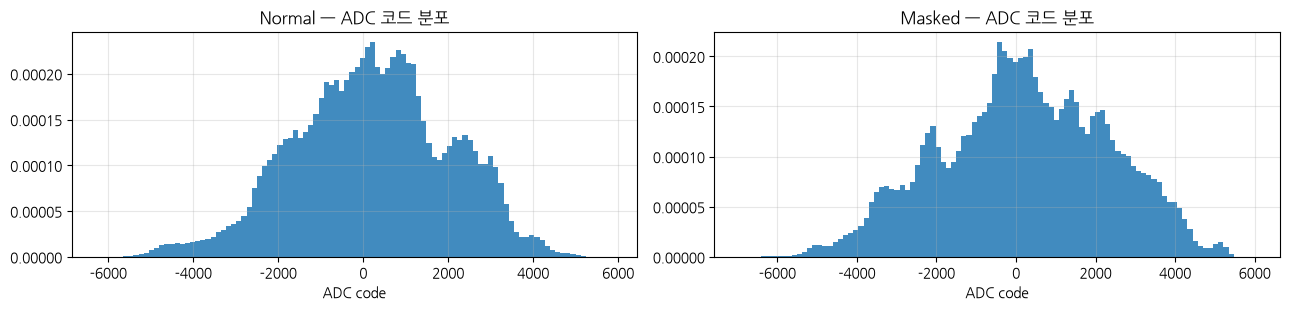

타겟       min      max     평균     표준편차


Normal     -6256     5848    193.4     1820.2


Masked     -6936     5992    205.7     2121.4


In [2]:
fig, axes = plt.subplots(1, len(data), figsize=(6.5 * len(data), 3.2))
if len(data) == 1:
    axes = [axes]
for ax, tid in zip(axes, data):
    t = data[tid]["t"].ravel()
    ax.hist(t, bins=100, density=True, alpha=0.85)
    ax.set_title("%s — ADC 코드 분포" % TARGETS[tid]["short"])
    ax.set_xlabel("ADC code"); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

print("타겟       min      max     평균     표준편차")
for tid in data:
    t = data[tid]["t"]
    print("%-8s %7d %8d %8.1f %10.1f" % (
        TARGETS[tid]["short"], t.min(), t.max(), t.mean(), t.std()))

---
## 3. `Quantizer` API 와 정보 보존 검증

| 단계 | 코드 |
|:----:|------|
| 학습 | `q = Quantizer.fit(traces_float, method)` |
| 변환 | `q.quantize(traces_float, clip=True)` |

`fit` 은 **클래스 메서드**다(인스턴스를 먼저 만들지 않는다). 학습에 쓰는 파형은 일부만으로
충분하며, 같은 측정 설정의 파형이면 된다.

`clip=True` 를 주면 범위를 넘는 값을 `int16` 경계로 자른다. `False` 면 넘칠 때 예외가 난다 —
**얼마나 잘리는지 모르는 채 넘어가는 것보다 낫다.**

> `QuantFitMethod` 의 메서드 이름은 `bounds` 와 `moment` 다. `.bounded` 같은 이름을 쓰면
> `AttributeError` 가 난다.

판단 기준은 "그래프가 비슷해 보이는가" 가 아니라 **분석 결과가 유지되는가** 이다.
1.0 이 찾아 둔 POI 에서 SNR 을 재어 비교한다.

In [3]:
def snr_at_poi(traces, labels, poi):
    """POI 열에서만 SNR 을 잰다. 전 구간을 돌 필요가 없다."""
    seg = np.ascontiguousarray(traces[:, poi].astype(np.int16))
    s = SNR(nc=256)
    s.fit_u(seg, np.ascontiguousarray(labels, dtype=np.uint16))
    return float(s.get_snr().max())


print("%-8s %-22s %10s %10s" % ("타겟", "방식", "원본 SNR", "양자화 후"))
for tid, d in data.items():
    tf = np.ascontiguousarray(d["t"].astype(np.float64))
    y = sbox_out(d["p"], d["k"]).astype(np.uint16)
    poi = poi_info[tid][0]
    base = snr_at_poi(d["t"], y, poi)
    for label, method in (("bounds(margin=4.0)", QuantFitMethod.bounds(margin=4.0)),
                          ("moment(nstd=6.0)", QuantFitMethod.moment(nstd=6.0))):
        q = Quantizer.fit(tf[:500], method=method)
        tq = q.quantize(tf, clip=True)
        got = snr_at_poi(tq, y, poi)
        print("%-8s %-22s %10.4f %10.4f" % (
            TARGETS[tid]["short"], label, base, got))
    print()

print("두 방식 모두 POI SNR 을 유지하면 이 파형에서는 어느 쪽을 써도 된다는 뜻이다.")

타겟       방식                         원본 SNR      양자화 후


Normal   bounds(margin=4.0)         1.3937     1.3937


Normal   moment(nstd=6.0)           1.3937     1.3937



Masked   bounds(margin=4.0)         0.2042     0.2042


Masked   moment(nstd=6.0)           0.2042     0.2042

두 방식 모두 POI SNR 을 유지하면 이 파형에서는 어느 쪽을 써도 된다는 뜻이다.


---
## 4. 배율을 직접 흔들어 본다

`Quantizer` 없이 배율을 손으로 정하면 어디서 무너지는지 본다.
배율마다 **포화율**(경계로 잘린 표본 비율)과 **POI SNR** 을 함께 잰다.

In [4]:
INT16_MAX = 32767

print("%-8s %10s %10s %10s %10s" % ("타겟", "배율", "포화율%", "계단수", "POI SNR"))
for tid, d in data.items():
    tf = d["t"].astype(np.float64)
    tf = tf - tf.mean()
    y = sbox_out(d["p"], d["k"]).astype(np.uint16)
    poi = poi_info[tid][0]
    span = np.abs(tf).max()
    base_scale = INT16_MAX / span          # 딱 맞게 채우는 배율
    for mult in (1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 3.0, 10.0, 50.0):
        scale = base_scale * mult
        raw = np.round(tf * scale)
        sat = float(np.mean(np.abs(raw) >= INT16_MAX)) * 100
        n_lvl = len(np.unique(raw[:50]))   # 실제로 쓰이는 정수 계단 수
        tq = np.clip(raw, -INT16_MAX, INT16_MAX).astype(np.int16)
        snr = snr_at_poi(tq, y, poi)
        note = ""
        if np.isnan(snr):
            note = "  ← 전부 잘려 분산 0 (NaN)"
        print("%-8s %10.4g %10.2f %10d %10.4f%s" % (
            TARGETS[tid]["short"], scale, sat, n_lvl, snr, note))
    print()

타겟               배율       포화율%        계단수    POI SNR


Normal    5.081e-05       0.00          1        nan  ← 전부 잘려 분산 0 (NaN)


Normal    0.0005081       0.00          7        nan  ← 전부 잘려 분산 0 (NaN)


Normal     0.005081       0.00         59     1.1820


Normal      0.05081       0.00        577     1.3970


...

Masked       0.4588       0.00       1542     0.2043


Masked        4.588       0.00       1542     0.2043


Masked        13.76      29.27       1542        nan  ← 전부 잘려 분산 0 (NaN)


Masked        45.88      73.14       1542        nan  ← 전부 잘려 분산 0 (NaN)


Masked        229.4      94.19       1542        nan  ← 전부 잘려 분산 0 (NaN)



### 표에서 읽을 것

**배율이 작을 때의 손실은 예상대로다.** "계단수" 열이 실제로 쓰이는 정수값 개수다.
배율이 아주 작으면 파형 전체가 서너 개의 정수값에만 걸리고 SNR 이 무너진다.
양자화 계단이 누설의 크기보다 굵어서 신호가 계단 사이에 묻힌다.

**잘림 쪽은 예상과 다르다.** 포화율이 20%를 넘어도 SNR 이 거의 그대로인 구간이 있다.
포화율이 90%를 넘어서면 POI 열의 값이 전부 같은 경계값이 되어 분산이 0 이 되고 `NaN` 이 나온다 —
그때가 정보가 실제로 사라진 시점이다.

이유는 이렇다. 잘리는 것은 파형의 **극단값**이고, 누설은 그 극단값이 아니라 **중간값에 따라
달라지는 작은 변동**에 실려 있다. 그 변동이 아직 `int16` 범위 안에서 표현되는 한 SNR 은
유지된다. 변동 자체가 경계에 눌리기 시작해야 비로소 정보가 사라진다.

> **교훈: 포화율 자체는 판정 기준이 아니다.** "몇 %가 잘렸는가" 가 아니라
> "**누설을 담은 변동이 잘렸는가**" 를 물어야 하고, 그 답은 분석 결과(SNR)로만 나온다.

**Masked 쪽 SNR 은 원래부터 잡음 바닥**(1.0 §6)이므로 이 표에서 값이 낮게 유지된다.
그것은 양자화가 망친 것이 아니다 — 애초에 1차 누설이 없다. 양자화 품질은 Normal 열로 판단한다.

---
## 5. 학습 파형이 적어도 되는가

`fit` 은 전체를 다 볼 필요가 없다. 다만 **"정수값이 똑같이 나오는가" 와 "분석 결과가 같은가"
는 다른 질문**이다. 둘 다 재어 본다.

학습 파형이 적으면 추정한 shift·scale 이 조금씩 달라지므로 정수값은 당연히 달라진다.
중요한 것은 그 차이가 **SNR 을 흔드는가** 이다.

In [5]:
for tid, d in data.items():
    tf = np.ascontiguousarray(d["t"].astype(np.float64))
    y = sbox_out(d["p"], d["k"]).astype(np.uint16)
    poi = poi_info[tid][0]
    ref = None
    print("=== %s ===" % TARGETS[tid]["short"])
    print("%10s %14s %12s" % ("학습 장수", "전체와 동일?", "POI SNR"))
    q_all = Quantizer.fit(tf, method=QuantFitMethod.bounds(margin=4.0))
    ref = q_all.quantize(tf, clip=True)
    for m in (50, 200, 1000, len(tf)):
        q = Quantizer.fit(tf[:m], method=QuantFitMethod.bounds(margin=4.0))
        tq = q.quantize(tf, clip=True)
        same = bool(np.array_equal(tq, ref))
        print("%10d %14s %12.4f" % (m, "예" if same else "아니오",
                                    snr_at_poi(tq, y, poi)))
    print()
print("정수값은 달라져도 SNR 이 흔들리지 않으면 학습 장수는 그 정도로 충분하다.")

=== Normal ===
     학습 장수        전체와 동일?      POI SNR


        50            아니오       1.3937


       200            아니오       1.3937


      1000            아니오       1.3937


      2000              예       1.3937



=== Masked ===
     학습 장수        전체와 동일?      POI SNR


        50            아니오       0.2043


       200            아니오       0.2043


      1000            아니오       0.2042


      2000              예       0.2043

정수값은 달라져도 SNR 이 흔들리지 않으면 학습 장수는 그 정도로 충분하다.


---
## 6. 요약

| 항목 | 내용 |
|------|------|
| 목적 | 실수 파형을 SCALib 이 요구하는 `int16` 으로, 정보를 잃지 않고 옮긴다 |
| API | `Quantizer.fit(traces_float, method)` → `.quantize(traces_float, clip)` |
| 방식 | `QuantFitMethod.bounds(margin)` · `QuantFitMethod.moment(nstd)` |
| 검증 | 그림이 아니라 **SNR 같은 분석 결과**가 유지되는지로 판단한다 |

### 이 데이터셋에서의 실제

`0.0` / `0.1` 수집 노트북은 이미 무손실 변환(ADC 코드 스케일 × 32768)으로 저장하므로,
다른 노트북들은 별도 정량화 없이 `int16` 파형을 그대로 쓴다.
이 노트북은 **다른 장비·다른 저장 형식의 파형을 다룰 때** 필요한 절차를 보인다.

### 실패 시 점검

1. `quantize(clip=False)` 에서 예외 → 범위를 넘는 값이 있다. `clip=True` 로 얼마나 잘리는지 먼저 재 본다.
2. 변환 후 SNR 이 떨어진다 → 배율이 너무 작아 계단이 성기거나, 너무 커서 잘리고 있다.
3. `AttributeError: bounded` → 메서드 이름은 `bounds` 다.

다음: `2.0.Ttest.ipynb` — 누설이 있는지 없는지 판정하는 TVLA.